In [1]:
import numpy as np
import matplotlib.pyplot as plt
from hiopbbpy.problems import Problem
from hiopbbpy.surrogate_modeling import smtKRG 
from hiopbbpy.opt import BnBAlgorithmBase, LCBacquisition

#### Example 

In [2]:
### parameters
n_samples = 10  # number of the initial samples to train GP
theta = 1.e-2  # hyperparameter for GP kernel
nx = 1         # dimension of the problem
c2D=np.array([1.25, 2.5])
c1D=np.array([1.25])
if nx == 1:
    delta = 10.0
    xlimits = np.array([[0.75 - delta/2.,0.75 + delta/2.]])
    c1D = np.array([0.75])
    c = c1D
elif nx == 2:
    c = c2D

class QuadraticShift(Problem):
    """
    f(x) = ||x - c||^2
    - Global minimizer: x* = c
    - Global minimum:   f* = 0
    """
    def __init__(self, ndim=2, xlimits=None, c=None, constraints=[]):
        if xlimits is None:
            xlimits = np.array([[-5.0, 5.0]] * ndim, dtype=float)
        name = "QuadraticShift"
        super().__init__(ndim, xlimits, name=name, constraints=constraints)

        # choose center if not provided
        if c is None:
            c = self.xlimits.mean(axis=1)
        self.c = np.asarray(c, dtype=float)
        assert self.c.shape == (ndim,), "c must be a {0:d}D point".format(ndim)

        # expose known solution for checking later
        # below is true when c is in xlimits
        self.x_star = self.c.copy()
        self.f_star = 0.0 

    def _evaluate(self, x: np.ndarray) -> np.ndarray:
        ne, nx = x.shape
        assert nx == self.ndim
        diff = x - self.c[None, :]
        y = np.sum(diff * diff, axis=1, dtype=float).reshape(ne, 1)
        return y

if nx == 1:
    problem = QuadraticShift(ndim=nx, xlimits=xlimits, c=c)
else:
    problem = QuadraticShift(ndim=nx, c=c)
problem.set_constraints([])  
    
x_train = problem.sample(n_samples)
y_train = problem.evaluate(x_train)

gp_model = smtKRG(theta, problem.xlimits, nx)
gp_model.train(x_train, y_train)

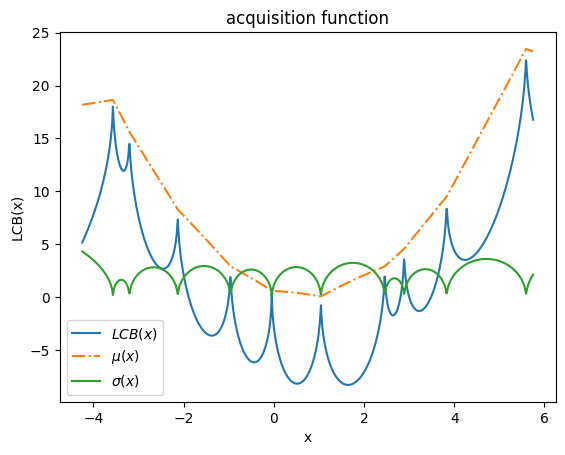

In [3]:
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)
n_plot_pts = 1000
X = np.atleast_2d(np.linspace(l[0], u[0], n_plot_pts)).transpose()

muX = gp_model.mean(X)
sigmaX = np.sqrt(gp_model.variance(X))
beta = 3.0

acqf = LCBacquisition(gp_model, beta=beta)
Y_acqf = acqf.evaluate(X)

plt.plot(X, Y_acqf, label=r'$LCB(x)$')
plt.plot(X, muX, "-.", label=r'$\mu(x)$')
plt.plot(X, sigmaX, label=r'$\sigma(x)$')
plt.xlabel("x")
plt.ylabel("LCB(x)")
plt.legend()
plt.title("acquisition function")
plt.show()

In [4]:
# Build a base "probe" and populate it from the trained SMT model
base = BnBAlgorithmBase(x=x_train, y=y_train)
base.gpsurrogate = gp_model
base.sync_from_smt()              # fills kernel_spec/p, theta, Xc, offsets, beta0/gamma, C, sigma2

# (Optional) ensure we try to compute a nontrivial lower bound for variance
base.BnB_LBmethod = None          # if "IPOPT", sigma2_L will be 0 in your current code
base.beta = beta
# Pick a box to test (use full domain here; swap l/u to any node box you want)
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)

nboxes = 50
box_sizes = (u - l) / float(nboxes)
midpoints = np.zeros((nboxes,))
kLs = np.zeros((nboxes, n_samples))
kUs = np.zeros((nboxes, n_samples))
muLs = np.zeros((nboxes,))
muUs = np.zeros((nboxes,))
s2Ls = np.zeros((nboxes,))
s2Us = np.zeros((nboxes,))
LCB_Ls = np.zeros((nboxes,) * nx)
LCB_Us = np.zeros((nboxes,) * nx)


for i in range(nboxes):
    for j in range(nboxes):
        if nx == 2:
            li = l + np.array([i * box_sizes[0], j * box_sizes[1]])
            ui = l + np.array([(i + 1) * box_sizes[0], (j +1) * box_sizes[1]])
        else:
            if j > 0:
                continue
            li = l + i * box_sizes[0]
            ui = l + (i + 1) * box_sizes[0]
        midpoints[i] = (li[0] + ui[0]) / 2.

        # 1) Bounds from your base class 
        kL, kU         = base.ker_bounds(li, ui)     # per-point kernel bounds vs each trainingsample
        mu_L, mu_U     = base.mu_bounds(kL, kU)      # scalar μ bounds on the box
        s2_L, s2_U     = base.sigma2_bounds(kL, kU,l=li,u=ui)  # scalar σ² bounds on the box
        
        # 2) (Optional) Node LCB/EI bounds using ONLY base.rs_* with your bounds
        LCB_L = base.rs_lcb(mu_L, np.sqrt(max(s2_U, 0.0)))     # lower bound on LCB over the box
        LCB_U = base.rs_lcb(mu_U, np.sqrt(max(s2_L, 0.0)))     # upper bound on LCB over the box
        
        if nx == 1:
            LCB_Ls[i] = LCB_L
            LCB_Us[i] = LCB_U
            midpoints[i] = (li[0] + ui[0]) / 2.
        elif nx == 2:
            LCB_Ls[i][j] = LCB_L
            LCB_Us[i][j] = LCB_U
        
        

        muLs[i] = mu_L
        muUs[i] = mu_U
        s2Ls[i] = s2_L
        s2Us[i] = s2_U
        kLs[i,:] = kL[:]
        kUs[i,:] = kU[:]       
mu = gp_model.mean(midpoints)
s2 = gp_model.variance(midpoints)

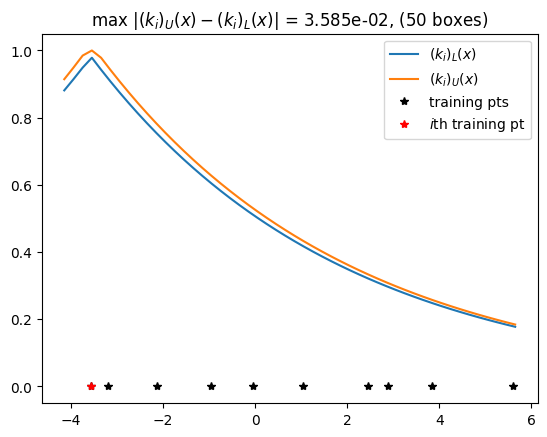

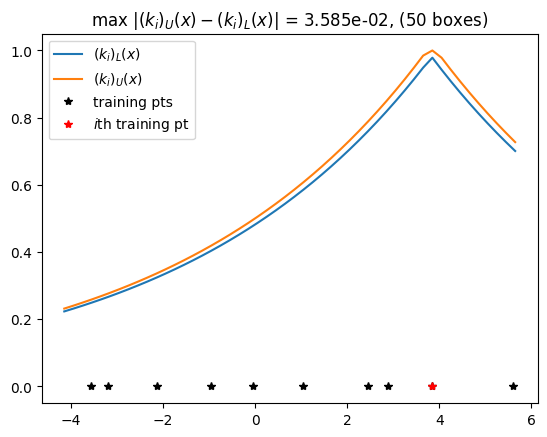

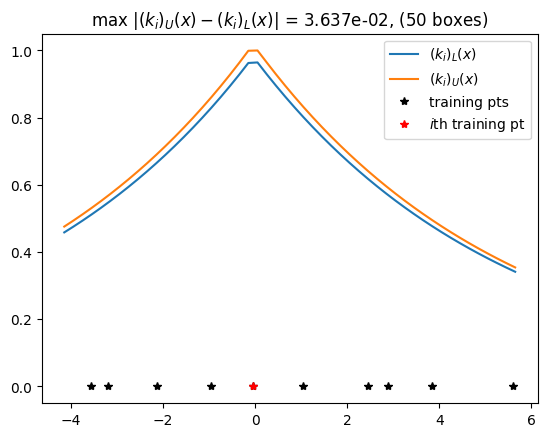

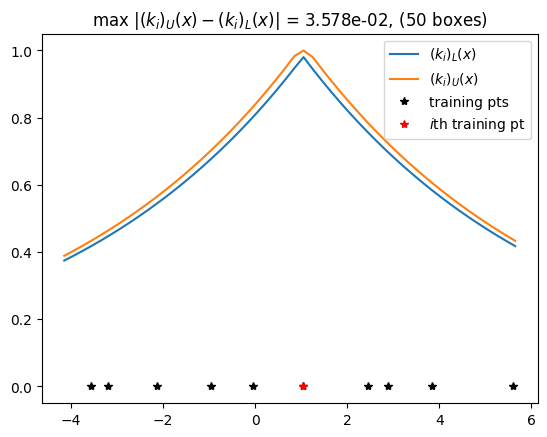

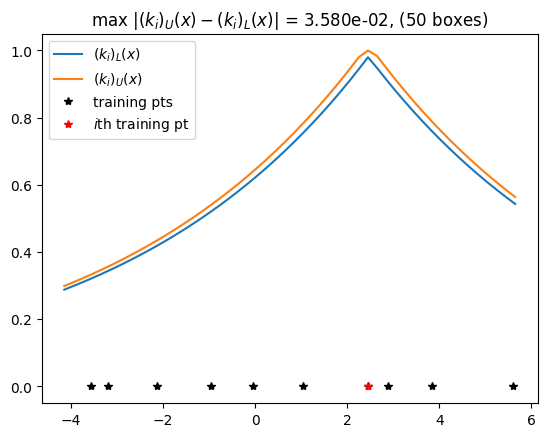

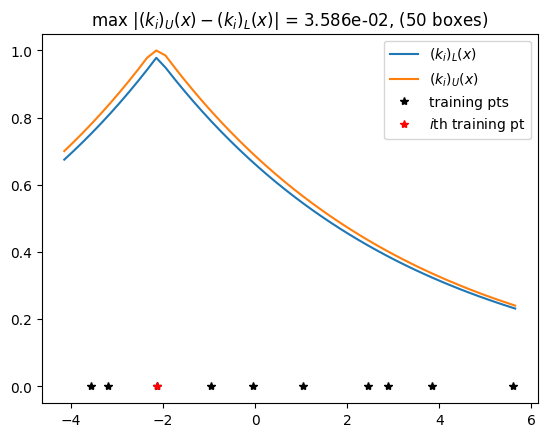

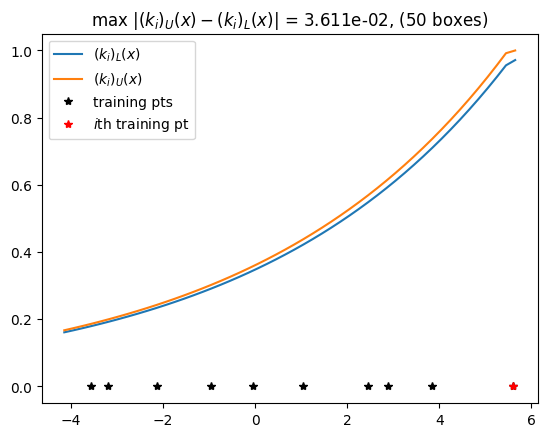

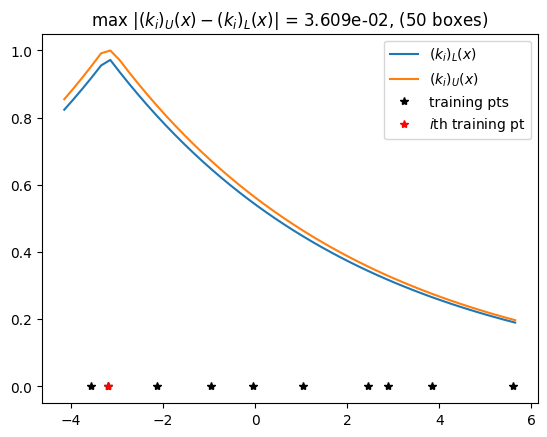

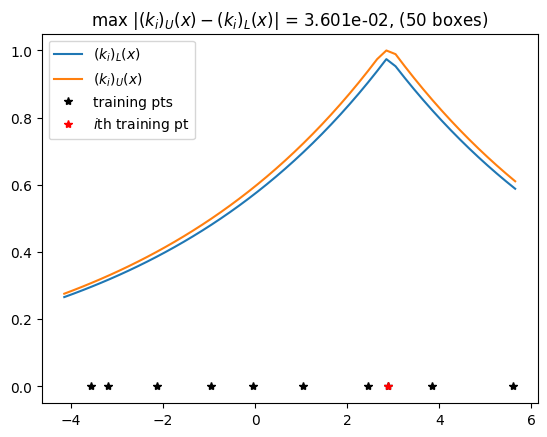

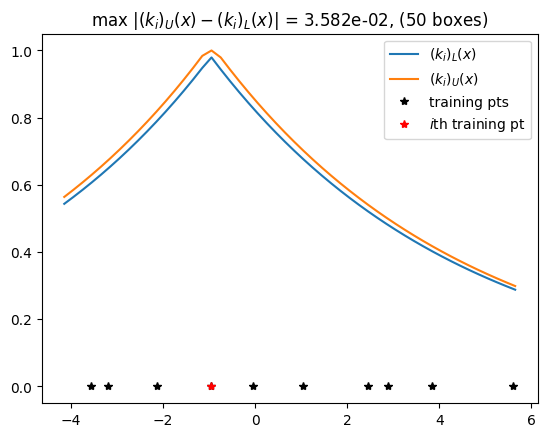

In [5]:
K_bandgaps = [np.linalg.norm(kUs[:,i] - kLs[:,i], np.inf) for i in range(n_samples)]

for i in range(n_samples):
    plt.plot(midpoints, kLs[:,i], label=r'$(k_i)_L(x)$')
    plt.plot(midpoints, kUs[:,i], label=r'$(k_i)_U(x)$')
    plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
    plt.plot(x_train[i,0], np.zeros(1), "r*", label=r'$i$th training pt')
    plt.legend()
    plt.title(r"max $|(k_i)_U(x) - (k_i)_L(x)|$ = {0:1.3e}, ({1:d} boxes)".format(K_bandgaps[i], nboxes))
    plt.show()

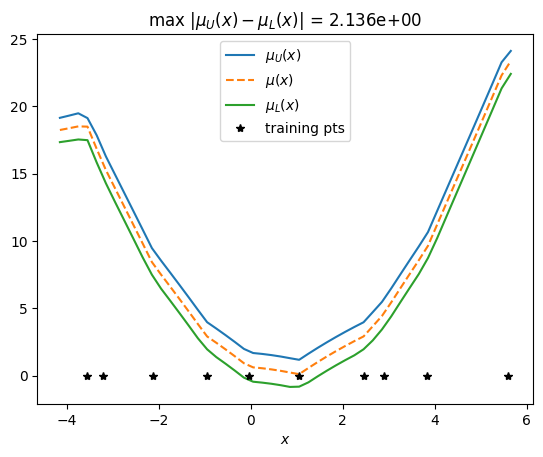

In [6]:
mu_bandgap = np.linalg.norm(muUs - muLs, np.inf)

plt.plot(midpoints, muUs, label=r'$\mu_U(x)$')
plt.plot(midpoints, mu, "--", label=r'$\mu(x)$')
plt.plot(midpoints, muLs, label=r'$\mu_L(x)$')
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.xlabel(r"$x$")
plt.legend()
plt.title(r"max $|\mu_U(x) - \mu_L(x)|$ = {0:1.3e}".format(mu_bandgap))
plt.show()

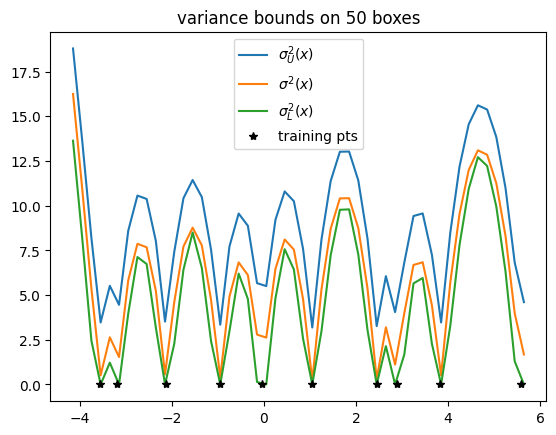

In [7]:
plt.plot(midpoints, s2Us, label=r"$\sigma^{2}_{U}(x)$")
plt.plot(midpoints, s2, label=r"$\sigma^{2}(x)$")
plt.plot(midpoints, s2Ls, label=r"$\sigma^{2}_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('variance bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()

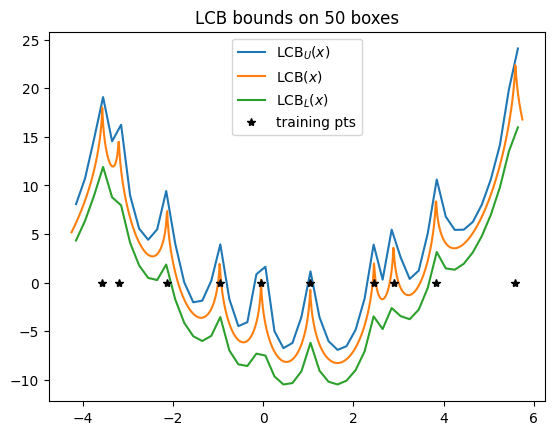

In [8]:
plt.plot(midpoints, LCB_Us, label=r"LCB$_{U}(x)$")
plt.plot(X, Y_acqf, label=r'LCB$(x)$')
plt.plot(midpoints, LCB_Ls, label=r"LCB$_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('LCB bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()

In [9]:
from hiopbbpy.opt import minimizer_wrapper

In [10]:
#acqf_callback = {'obj': acqf.scalar_evaluate}
#acqf_callback['grad'] = acqf.scalar_eval_g
#opt_solver = None
#acqf_minimizer=minimizer_wrapper(acqf_callback, opt_solver, problem.xlimits, [], {})

In [11]:
from hiopbbpy.opt import BnBAlgorithm
bnb = BnBAlgorithm(acqf)
bnb.epsilon_diam = 1.e-2
bnb.epsilon_gap = 1.e-2
bnb.BnB_LBmethod = None

In [12]:
LCB_Ls2 = np.zeros((nboxes,) * nx)
LCB_Us2 = np.zeros((nboxes,) * nx)

for i in range(nboxes):
    for j in range(nboxes):
        if nx == 2:
            li = l + np.array([i * box_sizes[0], j * box_sizes[1]])
            ui = l + np.array([(i + 1) * box_sizes[0], (j +1) * box_sizes[1]])
        else:
            if j > 0:
                continue
            li = l + i * box_sizes[0]
            ui = l + (i + 1) * box_sizes[0]
        midpoints[i] = (li[0] + ui[0]) / 2.

        # 1) Bounds from your base class 
        kL, kU         = bnb.ker_bounds(li, ui)     # per-point kernel bounds vs each trainingsample
        mu_L, mu_U     = bnb.mu_bounds(kL, kU)      # scalar μ bounds on the box
        s2_L, s2_U     = bnb.sigma2_bounds(kL, kU)  # scalar σ² bounds on the box
        
        # 2) (Optional) Node LCB/EI bounds using ONLY base.rs_* with your bounds
        LCB_L = bnb.rs_lcb(mu_L, np.sqrt(s2_U))
        LCB_U = bnb.rs_lcb(mu_U, np.sqrt(s2_L))
        LCB_L2 = bnb.compute_acq_lower_bound(li, ui)
        LCB_U2 = bnb.compute_acq_upper_bound(li, ui)
        #LCB_L = bnb.rs_lcb(mu_L, np.sqrt(max(s2_U, 0.0)))     # lower bound on LCB over the box
        #LCB_U = bnb.rs_lcb(mu_U, np.sqrt(max(s2_L, 0.0)))     # upper bound on LCB over the box
        #print(f"LCB node bounds:  L={LCB_L:.9f}   U={LCB_U:.9f}")
        if nx == 1:
            LCB_Ls[i] = LCB_L
            LCB_Us[i] = LCB_U
            LCB_Ls2[i] = LCB_L2
            LCB_Us2[i] = LCB_U2
            midpoints[i] = (li[0] + ui[0]) / 2.
        elif nx == 2:
            LCB_Ls[i][j] = LCB_L
            LCB_Us[i][j] = LCB_U
        
        

        muLs[i] = mu_L
        muUs[i] = mu_U
        s2Ls[i] = s2_L
        s2Us[i] = s2_U
        kLs[i,:] = kL[:]
        kUs[i,:] = kU[:] 

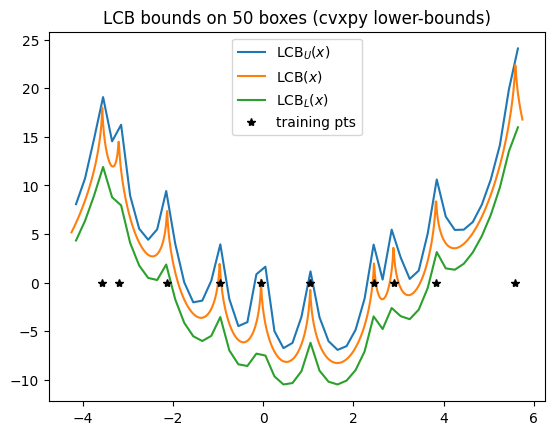

In [13]:
plt.plot(midpoints, LCB_Us2, label=r"LCB$_{U}(x)$")
plt.plot(X, Y_acqf, label=r'LCB$(x)$')
plt.plot(midpoints, LCB_Ls2, label=r"LCB$_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
if bnb.BnB_LBmethod == None:
    plt.title('LCB bounds on {0:d} boxes (cvxpy lower-bounds)'.format(nboxes))
else:
    plt.title('LCB bounds on {0:d} boxes (IPOPT lower-bounds)'.format(nboxes))
plt.legend()
plt.show()

In [14]:
bnb.max_bnbiter = 500
xstar = bnb.optimize()#bnb.bnboptimize(problem.xlimits[:,0], problem.xlimits[:,1])

=== Starting Branch & Bound Optimization (Minimization) ===
Initial bounds: l = [-4.25], u = [5.75]
Number of points: 10, Dim = 1

Initial acquisition lower bound: -54.858501340218396
Initial acquisition upper bound: 50.78859715272719

--- BnB Iteration 1 ---
Node bounds: l=[-4.25], u=[5.75]
Node acquisition bounds: L=-54.858501340218396, U=50.78859715272719
Current best feasible value (GUB): 50.78859715272719
  Branching to child: l=[-4.25], u=[0.75]
  Child acquisition bounds: L=-36.585445884583294, U=29.26347329876716
  Branching to child: l=[0.75], u=[5.75]
  Child acquisition bounds: L=-35.949106799615464, U=31.511508732115093
Queue size: 2 | GLB=-36.585445884583294 | GUB=29.26347329876716 | Gap=65.84891918335046

--- BnB Iteration 2 ---
Node bounds: l=[-4.25], u=[0.75]
Node acquisition bounds: L=-36.585445884583294, U=29.26347329876716
Current best feasible value (GUB): 29.26347329876716
  Branching to child: l=[-4.25], u=[-1.75]
  Child acquisition bounds: L=-15.065870794434964,

  Child acquisition bounds: L=-9.851647664945709, U=-7.227620913983158
  Branching to child: l=[1.84375], u=[2.]
  Child acquisition bounds: L=-9.292957176087121, U=-6.387460963070169
Queue size: 17 | GLB=-11.141844385591918 | GUB=-7.227620913983158 | Gap=3.91422347160876

--- BnB Iteration 19 ---
Node bounds: l=[0.125], u=[0.4375]
Node acquisition bounds: L=-11.141844385591918, U=-4.050150359657119
Current best feasible value (GUB): -7.227620913983158
  Branching to child: l=[0.125], u=[0.28125]
  Child acquisition bounds: L=-8.728979707219358, U=-4.848748029559948
  Branching to child: l=[0.28125], u=[0.4375]
  Child acquisition bounds: L=-9.708996857078336, U=-6.537077434081413
Queue size: 18 | GLB=-11.122581605522198 | GUB=-7.227620913983158 | Gap=3.8949606915390396

--- BnB Iteration 20 ---
Node bounds: l=[-1.125], u=[-0.5]
Node acquisition bounds: L=-11.122581605522198, U=5.79482225611664
Current best feasible value (GUB): -7.227620913983158
  Branching to child: l=[-1.125], u=[-

  Child acquisition bounds: L=-8.214827145166392, U=-6.722837510212209
Queue size: 22 | GLB=-9.144421932589044 | GUB=-7.759602967203301 | Gap=1.384818965385743

--- BnB Iteration 35 ---
Node bounds: l=[1.609375], u=[1.6875]
Node acquisition bounds: L=-9.144421932589044, U=-7.759602967203301
Current best feasible value (GUB): -7.759602967203301
  Branching to child: l=[1.609375], u=[1.6484375]
  Child acquisition bounds: L=-8.706389383643204, U=-8.00533484165959
  Branching to child: l=[1.6484375], u=[1.6875]
  Child acquisition bounds: L=-8.70277053567553, U=-8.019736626600007
Queue size: 22 | GLB=-9.14027420644881 | GUB=-8.019736626600007 | Gap=1.1205375798488024

--- BnB Iteration 36 ---
Node bounds: l=[-0.8125], u=[-0.5]
Node acquisition bounds: L=-9.14027420644881, U=-1.9776689333863011
Current best feasible value (GUB): -8.019736626600007
  Branching to child: l=[-0.8125], u=[-0.65625]
  Child acquisition bounds: L=-6.568665203187087, U=-2.613859604891103
  Child pruned: L ≥ GUB -

  Child acquisition bounds: L=-8.439083618624572, U=-8.10801305580518
Queue size: 30 | GLB=-8.637357302021318 | GUB=-8.14254511152604 | Gap=0.4948121904952778

--- BnB Iteration 52 ---
Node bounds: l=[1.375], u=[1.453125]
Node acquisition bounds: L=-8.637357302021318, U=-6.960043920801464
Current best feasible value (GUB): -8.14254511152604
  Branching to child: l=[1.375], u=[1.4140625]
  Child acquisition bounds: L=-8.06383826486316, U=-7.208766458172544
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[1.4140625], u=[1.453125]
  Child acquisition bounds: L=-8.259506489643245, U=-7.438154747993558
Queue size: 30 | GLB=-8.627648721018483 | GUB=-8.14254511152604 | Gap=0.4851036094924428

--- BnB Iteration 53 ---
Node bounds: l=[0.515625], u=[0.5546875]
Node acquisition bounds: L=-8.627648721018483, U=-7.910952876379493
Current best feasible value (GUB): -8.14254511152604
  Branching to child: l=[0.515625], u=[0.53515625]
  Child acquisition bounds: L=-8.391323942194155, U=-8.03606

  Child acquisition bounds: L=-8.375358848885462, U=-8.200747697893464
  Branching to child: l=[1.63867188], u=[1.6484375]
  Child acquisition bounds: L=-8.376772154572413, U=-8.203308502176395
Queue size: 37 | GLB=-8.486152550488146 | GUB=-8.203308502176395 | Gap=0.2828440483117518

--- BnB Iteration 68 ---
Node bounds: l=[1.6484375], u=[1.66796875]
Node acquisition bounds: L=-8.486152550488146, U=-8.14254511152604
Current best feasible value (GUB): -8.203308502176395
  Branching to child: l=[1.6484375], u=[1.65820312]
  Child acquisition bounds: L=-8.376330969536447, U=-8.203992342490134
  Branching to child: l=[1.65820312], u=[1.66796875]
  Child acquisition bounds: L=-8.374046860553477, U=-8.202811673294004
Queue size: 38 | GLB=-8.481168179021388 | GUB=-8.203992342490134 | Gap=0.27717583653125466

--- BnB Iteration 69 ---
Node bounds: l=[1.609375], u=[1.62890625]
Node acquisition bounds: L=-8.481168179021388, U=-8.128374747971273
Current best feasible value (GUB): -8.20399234249013

  Branching to child: l=[0.4765625], u=[0.48632812]
  Child acquisition bounds: L=-8.254313802438432, U=-8.07811854871746
  Branching to child: l=[0.48632812], u=[0.49609375]
  Child acquisition bounds: L=-8.262598954757802, U=-8.087816741680577
Queue size: 51 | GLB=-8.376772154572413 | GUB=-8.203992342490134 | Gap=0.172779812082279

--- BnB Iteration 84 ---
Node bounds: l=[1.63867188], u=[1.6484375]
Node acquisition bounds: L=-8.376772154572413, U=-8.203308502176395
Current best feasible value (GUB): -8.203992342490134
Skip: Node diameter 0.009765625 <= 0.01

--- BnB Iteration 85 ---
Node bounds: l=[1.6484375], u=[1.65820312]
Node acquisition bounds: L=-8.376330969536447, U=-8.203992342490134
Current best feasible value (GUB): -8.203992342490134
Skip: Node diameter 0.009765625 <= 0.01

--- BnB Iteration 86 ---
Node bounds: l=[0.6328125], u=[0.671875]
Node acquisition bounds: L=-8.375889438411804, U=-7.575588807679276
Current best feasible value (GUB): -8.203992342490134
  Branching to

  Child acquisition bounds: L=-8.213321839526127, U=-8.032700770632585
  Child pruned: L ≥ GUB - eps.
Queue size: 36 | GLB=-8.322140497306055 | GUB=-8.203992342490134 | Gap=0.11814815481592156

--- BnB Iteration 108 ---
Node bounds: l=[1.71679688], u=[1.7265625]
Node acquisition bounds: L=-8.322140497306055, U=-8.15711698020452
Current best feasible value (GUB): -8.203992342490134
Skip: Node diameter 0.009765625 <= 0.01

--- BnB Iteration 109 ---
Node bounds: l=[1.56054688], u=[1.5703125]
Node acquisition bounds: L=-8.312297463652802, U=-8.128938630498443
Current best feasible value (GUB): -8.203992342490134
Skip: Node diameter 0.009765625 <= 0.01

--- BnB Iteration 110 ---
Node bounds: l=[1.7265625], u=[1.73632812]
Node acquisition bounds: L=-8.307182136174571, U=-8.143132344523465
Current best feasible value (GUB): -8.203992342490134
Skip: Node diameter 0.009765625 <= 0.01

--- BnB Iteration 111 ---
Node bounds: l=[1.55078125], u=[1.56054688]
Node acquisition bounds: L=-8.29547379693

  Child acquisition bounds: L=-8.123016739965324, U=-7.955184821990879
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[1.81445312], u=[1.82421875]
  Child acquisition bounds: L=-8.091901793278158, U=-7.923049702817092
  Child pruned: L ≥ GUB - eps.
Queue size: 2 | GLB=-8.21601933565008 | GUB=-8.203992342490134 | Gap=0.012026993159945931

--- BnB Iteration 142 ---
Node bounds: l=[0.57421875], u=[0.58398438]
Node acquisition bounds: L=-8.21601933565008, U=-8.029866836238472
Current best feasible value (GUB): -8.203992342490134
Skip: Node diameter 0.009765625 <= 0.01

--- BnB Iteration 143 ---
Node bounds: l=[1.921875], u=[2.]
Node acquisition bounds: L=-8.214827145166392, U=-6.722837510212209
Current best feasible value (GUB): -8.203992342490134
  Branching to child: l=[1.921875], u=[1.9609375]
  Child acquisition bounds: L=-7.883010093078745, U=-7.148696730530999
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[1.9609375], u=[2.]
  Child acquisition bounds: L=-7.647866935

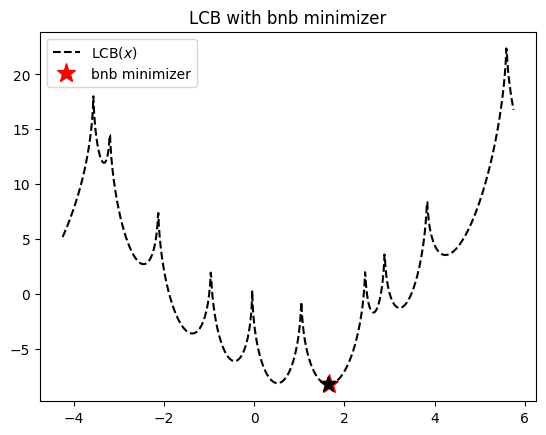

In [15]:
y_star = acqf.evaluate(xstar)
xstar_true = np.atleast_2d(X[np.argmin(Y_acqf)])
ystar_true = acqf.evaluate(xstar_true)
#print(xstar_true)
plt.plot(X, Y_acqf, 'k--', label=r'LCB$(x)$')
plt.plot(xstar, y_star, "r*", markersize=14, label=r'bnb minimizer')
plt.plot(xstar_true, ystar_true, "k*", markersize=12)
#for i in range(2):
#    plt.plot(xstar_bounds.flatten()[i], y_star[0,0] , "k*")
plt.title('LCB with bnb minimizer'.format(nboxes))
plt.legend()
plt.show()


In [16]:
bo_maxiter = 3
batch_size = 1
options = {
    'acquisition_type': 'LCB',
    'acquisition_method' : 'bnb',
    'bo_maxiter': bo_maxiter, 
    'batch_size': batch_size,
    'opt_solver': "SLSQP"    
}

In [17]:
from hiopbbpy.opt import BOAlgorithm
bo = BOAlgorithm(problem, gp_model, x_train, y_train, options=options)
bo.optimize()

hiopbbpy Problem name: QuadraticShift
hiopbbpy Max BO iter: 3
hiopbbpy Optimizing acquisition (LCB) with 10 random initial points
hiopbbpy Batch type: KB
hiopbbpy Batch size: 1
hiopbbpy Internal optimization solver: SLSQP
hiopbbpy Internal optimization solver options: {'maxiter': 200}
hiopbbpy Initial training set: 10 samples, 1 dimensions
hiopbbpy Logger level: INFO
hiopbbpy Best UNCONSTRAINED objective from 10 initial samples: 8.5679e-02 
hiopbbpy Best CONSTRAINED objective from 10 feasible initial samples: 8.5679e-02
hiopbbpy *****************************
hiopbbpy Iteration 1/3
hiopbbpy In batch 1/1
hiopbbpy Start finding the best sampling point:


=== Starting Branch & Bound Optimization (Minimization) ===
Initial bounds: l = [-4.25], u = [5.75]
Number of points: 10, Dim = 1
This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:        1
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        1
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr 

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:        1
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        1
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  3.2580294e+00 0.00e+00 5.87e+00   0.0 0.00e+00    -  0.00e+00 0.00e+00 

   0 -5.0166906e-01 0.00e+00 7.53e+00   0.0 0.00e+00    -  0.00e+00 0.00e+00   0
   1 -8.1469223e+00 0.00e+00 8.59e-01   0.7 5.79e+00    -  7.39e-01 5.00e-01f  2
   2 -8.1498716e+00 0.00e+00 1.74e-01  -1.6 1.58e-01    -  1.00e+00 1.25e-01f  4
   3 -8.1501716e+00 0.00e+00 3.83e-04  -2.8 4.59e-03    -  9.96e-01 1.00e+00f  1
   4 -8.1501716e+00 0.00e+00 2.46e-07  -8.7 8.30e-06    -  9.98e-01 1.00e+00f  1
  Child acquisition bounds: L=-15.820283593267595, U=-8.150171648131787
Queue size: 4 | GLB=-28.288315774556363 | GUB=-8.265489434347726 | Gap=20.02282634020864

--- BnB Iteration 4 ---
Node bounds: l=[0.75], u=[3.25]
Node acquisition bounds: L=-28.288315774556363, U=-8.150171648131787
Current best feasible value (GUB): -8.265489434347726
   5 -8.1501716e+00 0.00e+00 1.20e-12 -11.0 3.15e-09    -  1.00e+00 1.00e+00f  1

Number of Iterations....: 5

                                   (scaled)                 (unscaled)
Objective...............:  -8.1501716481317867e+00   -8.1501716481317867

   0 -5.8867167e+00 0.00e+00 4.29e+00   0.0 0.00e+00    -  0.00e+00 0.00e+00   0
   1 -7.0903063e+00 0.00e+00 7.54e+00   0.4 3.21e+00    -  8.58e-01 2.50e-01f  3
   2 -8.2528884e+00 0.00e+00 5.36e-01  -1.1 7.22e+00    -  1.00e+00 1.89e-01f  3
   3 -8.2602474e+00 0.00e+00 4.88e-01  -1.7 1.18e-01    -  1.00e+00 5.00e-01f  2
   4 -8.2654886e+00 0.00e+00 5.60e-03  -2.6 2.29e-02    -  9.99e-01 1.00e+00f  1
   5 -8.2654894e+00 0.00e+00 3.98e-05  -4.8 2.90e-04    -  1.00e+00 1.00e+00f  1
  Child acquisition bounds: L=-16.032040450731266, U=-8.265489434347725
  Branching to child: l=[-0.5], u=[0.75]
   6 -8.2654894e+00 0.00e+00 3.92e-09 -10.8 2.09e-06    -  1.00e+00 1.00e+00f  1

Number of Iterations....: 6

                                   (scaled)                 (unscaled)
Objective...............:  -8.2654894343477245e+00   -8.2654894343477245e+00
Dual infeasibility......:   3.9232873427564981e-09    3.9232873427564981e-09
Constraint violation....:   0.0000000000000000e+00    0.000000000

...

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:        1
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        1
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -3.9590900e+00 0.00e+00 1.97e+01   0.0 0.00e+00    -  0.00e+00 0.00e+00 

   1 -5.1998593e+00 0.00e+00 4.40e+00   0.5 3.41e+00    -  9.68e-01 6.25e-02f  5
   2 -5.3117197e+00 0.00e+00 2.85e-01  -1.0 7.36e-02    -  9.85e-01 1.00e+00f  1
   3 -5.3128844e+00 0.00e+00 7.69e-03  -3.0 8.46e-03    -  1.00e+00 1.00e+00f  1
   4 -5.3128853e+00 0.00e+00 3.40e-05  -5.1 2.25e-04    -  9.99e-01 1.00e+00f  1
  Child acquisition bounds: L=-5.459148245186832, U=-5.312885266882421
  Child pruned: L ≥ GUB - eps.
Queue size: 10 | GLB=-6.06676636114253 | GUB=-5.972098252196817 | Gap=0.09466810894571331

--- BnB Iteration 83 ---
Node bounds: l=[0.65234375], u=[0.66210938]
Node acquisition bounds: L=-6.06676636114253, U=-5.972098252196796
Current best feasible value (GUB): -5.972098252196817
Skip: Node diameter 0.009765625 <= 0.01

--- BnB Iteration 84 ---
Node bounds: l=[0.74023438], u=[0.75]
Node acquisition bounds: L=-6.05410220680966, U=-5.9720982521968065
Current best feasible value (GUB): -5.972098252196817
Skip: Node diameter 0.009765625 <= 0.01

--- BnB Iteration 85 ---
N

   2 -5.9720887e+00 0.00e+00 3.86e-02  -1.6 1.57e-02    -  9.91e-01 1.00e+00f  1
  Child acquisition bounds: L=-5.87639588515836, U=-5.972098252196805
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[0.79882812], u=[0.80859375]
   3 -5.9720983e+00 0.00e+00 5.66e-05  -3.4 6.13e-04    -  9.96e-01 1.00e+00f  1
   4 -5.9720983e+00 0.00e+00 2.07e-08  -9.3 4.59e-07    -  9.99e-01 1.00e+00f  1
   5 -5.9720983e+00 0.00e+00 1.00e-14 -11.0 6.47e-12    -  1.00e+00 1.00e+00f  1

Number of Iterations....: 5

                                   (scaled)                 (unscaled)
Objective...............:  -5.9720982521968047e+00   -5.9720982521968047e+00
Dual infeasibility......:   9.9958708697710807e-15    9.9958708697710807e-15
Constraint violation....:   0.0000000000000000e+00    0.0000000000000000e+00
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   1.0000000518064245e-11    1.0000000518064245e-11
Overall NLP error.......:   1.000000

hiopbbpy   (mu, sigma) at new sample x: 0.5720196690197197, 1.0511698827610563 
hiopbbpy Best objective found in this iteration: 5.5084e-01 
hiopbbpy Training set size is now 13
hiopbbpy Current best objective: 1.6031e-01 (previous best: 1.6031e-01)
hiopbbpy Objective function improvement: 0.0000e+00
hiopbbpy ===================================
hiopbbpy Bayesian Optimization completed
hiopbbpy Total evaluations for initial samples: 10
hiopbbpy Total evaluations for BO iterations: 3
hiopbbpy Optimal at BO iteration: 2 
hiopbbpy Best value: 0.16031265258789062
hiopbbpy ===================================


  0
   1 -5.7279565e+00 0.00e+00 6.89e+00   0.7 5.97e+00    -  8.10e-01 1.17e-01f  4
   2 -5.9397765e+00 0.00e+00 1.85e+00  -0.5 2.66e-01    -  9.71e-01 5.00e-01f  2
   3 -5.9720711e+00 0.00e+00 5.19e-02  -2.3 3.47e-02    -  1.00e+00 1.00e+00f  1
   4 -5.9720983e+00 0.00e+00 2.40e-04  -4.2 1.03e-03    -  1.00e+00 1.00e+00f  1
   5 -5.9720983e+00 0.00e+00 5.61e-09 -10.2 4.74e-06    -  1.00e+00 1.00e+00f  1
  Child acquisition bounds: L=-5.1709754977645765, U=-5.972098252196805
  Child pruned: L ≥ GUB - eps.
Queue size: 1 | GLB=-5.98443597400283 | GUB=-5.972098252196832 | Gap=0.012337721805997681

--- BnB Iteration 92 ---
Node bounds: l=[0.62304688], u=[0.6328125]
Node acquisition bounds: L=-5.98443597400283, U=-5.972098252196802
Current best feasible value (GUB): -5.972098252196832
Skip: Node diameter 0.009765625 <= 0.01

=== Optimization Finished ===
Total nodes explored: 155
Best bounds: l=[-0.03125], u=[0.046875]
Best feasible acquisition value (GUB): -5.972098252196832
Final gap: 0.

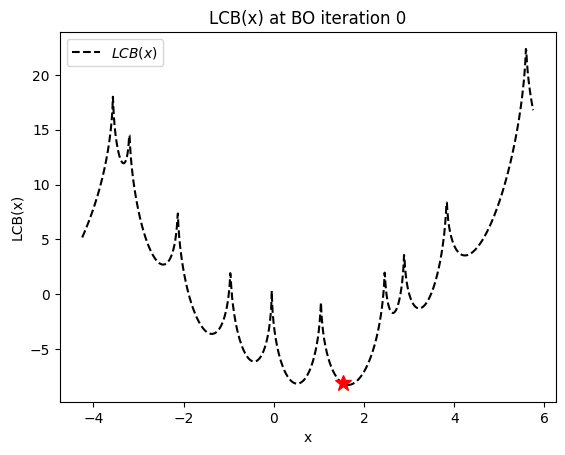

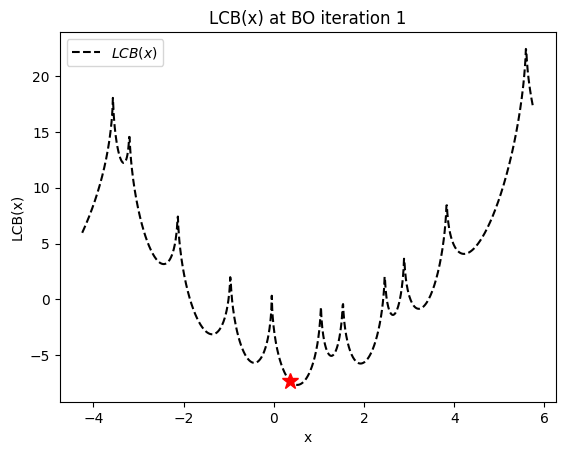

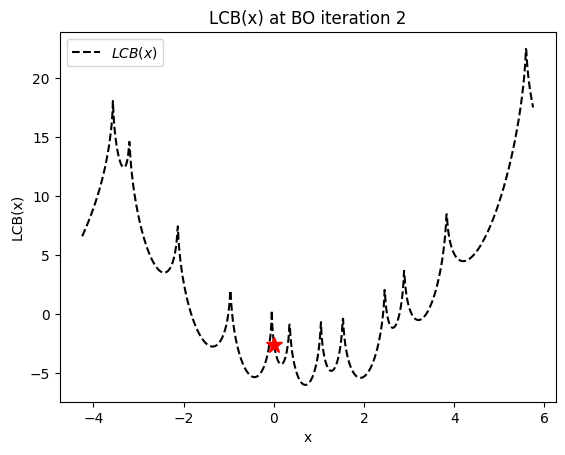

In [18]:
x_bo = bo.getOptimizationHistory()[0]
x_train_superset = np.concatenate((x_train, x_bo), axis=0)
for i in range(bo_maxiter):
    x_train2 = x_train_superset[:-bo_maxiter+i]
    y_train2 = problem.evaluate(x_train2)
    gp_model2 = smtKRG(theta, problem.xlimits, nx)
    gp_model2.train(x_train2, y_train2)
    acqf2 = LCBacquisition(gp_model2, beta=beta)
    Y_acqf2 = acqf2.evaluate(X)
    y_star2 = acqf2.evaluate(np.atleast_2d(x_bo[i]))
    plt.plot(X, Y_acqf2,'k--', label=r'$LCB(x)$')
    plt.plot(x_bo[i], y_star2, r'r*', markersize=12)
    #plt.plot(X, muX, "-.", label=r'$\mu(x)$')
    #plt.plot(X, sigmaX, label=r'$\sigma(x)$')
    plt.xlabel("x")
    plt.ylabel("LCB(x)")
    plt.legend()
    plt.title(r"LCB(x) at BO iteration {0:d}".format(i))
    plt.show()
    
    